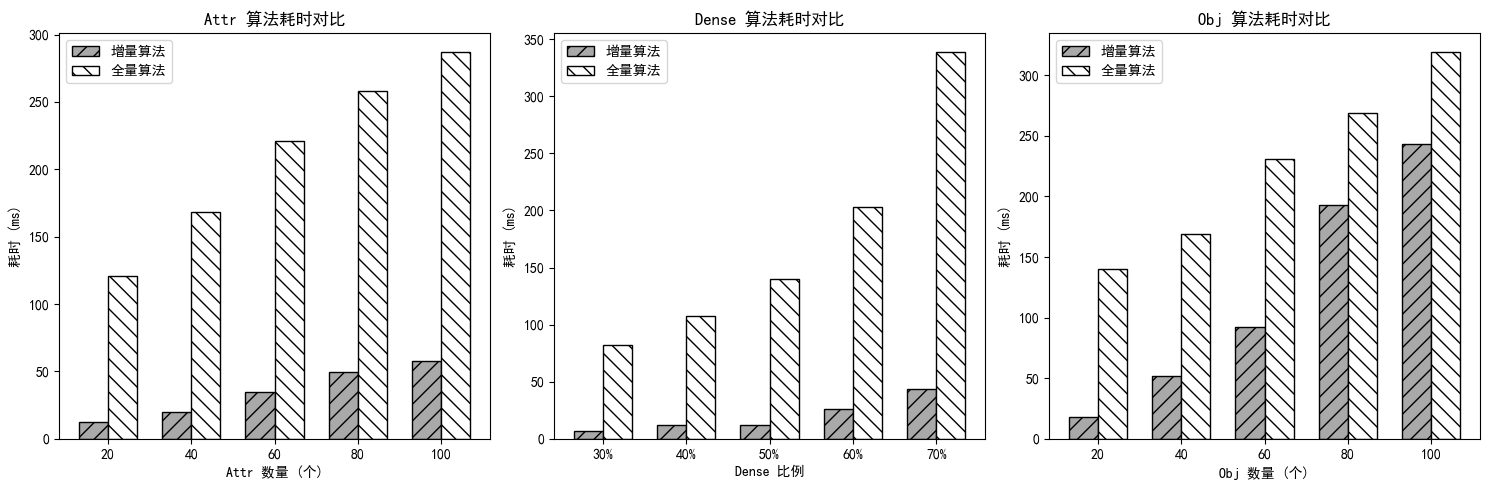

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 设置支持中文的字体，避免标签显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Songti SC', 'Arial Unicode MS'] # 适配 Windows/Mac
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

def read_and_average(filepath):
    """
    读取文件并计算两列的平均值
    """
    col1, col2 = [], []
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                # 过滤空行
                if line:
                    parts = line.split(',')
                    if len(parts) == 2:
                        col1.append(float(parts[0]))
                        col2.append(float(parts[1]))
    # 如果文件有数据，则返回平均值；否则返回(0,0)
    if col1 and col2:
        return np.mean(col1), np.mean(col2)
    return 0, 0

# 定义三大类对应的横坐标值
attr_x = [20, 40, 60, 80, 100]
obj_x = [20, 40, 60, 80, 100]
dense_x = [0.3, 0.4, 0.5, 0.6, 0.7]

# 读取文件所在的文件夹路径（如果在同级目录的input文件夹下）
# 请确保您的文件放在与Jupyter NoteBook同级的 'input' 文件夹中
base_dir = '../data/input'

# 获取各类别的均值
attr_means = [read_and_average(f'{base_dir}/attr_{x}.txt') for x in attr_x]
obj_means = [read_and_average(f'{base_dir}/obj_{x}.txt') for x in obj_x]
dense_means = [read_and_average(f'{base_dir}/dense_{x}.txt') for x in dense_x]

# 解包均值数据
attr_inc, attr_full = zip(*attr_means)
obj_inc, obj_full = zip(*obj_means)
dense_inc, dense_full = zip(*dense_means)

# 创建 1行3列 的画布，尺寸为15x5
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
width = 0.35 # 柱子的宽度

def plot_double_bars(ax, x_labels, inc_data, full_data, title, xlabel):
    """
    在指定的子图上绘制双柱状图
    """
    x = np.arange(len(x_labels))
    
    # 增量算法柱：深灰色背景 + 正向斜杠
    ax.bar(x - width/2, inc_data, width, label='增量算法', 
           color='darkgray', edgecolor='black', hatch='//')
    
    # 全量算法柱：白色背景 + 反向斜杠
    ax.bar(x + width/2, full_data, width, label='全量算法', 
           color='white', edgecolor='black', hatch='\\\\')
    
    # 设置图表文字与刻度
    ax.set_ylabel('耗时 (ms)')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend()

# 1. 绘制 attr 柱状图
plot_double_bars(axes[0], attr_x, attr_inc, attr_full, '算法耗时对比', 'Attr 数量 (个)')

# 2. 绘制 dense 柱状图 (横坐标转换为百分比显示)
dense_labels = ['30%', '40%', '50%', '60%', '70%']
plot_double_bars(axes[1], dense_labels, dense_inc, dense_full, '算法耗时对比', 'Dense 比例')

# 3. 绘制 obj 柱状图
plot_double_bars(axes[2], obj_x, obj_inc, obj_full, '算法耗时对比', 'Obj 数量 (个)')

# 自动调整子图间距
plt.tight_layout()

# 在Jupyter中展示
plt.show()